In [2]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [1]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_kaggle_v2.csv"

In [3]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.columns 

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Sleep_Hours',
       'Daily_Screen_Hours', 'Weekend_Screen_Hours', 'Social_Media_Hours',
       'Caffeine_Cups_Per_Day', 'Work_Productivity_Score', 'App_Usage_Count',
       'Exercise_Hours_Per_Week', 'Daily_Work_Hours', 'Commute_Hours_Per_Day',
       'Stress_Level', 'Stressed'],
      dtype='object')

<h3> Irrelevant Columns

In [5]:
irrelevant = ['User_ID', 'Weekend_Screen_Hours', 'Stress_Level']

In [6]:
df = df.drop(columns=irrelevant)

In [7]:
df.Stressed.value_counts()

Stressed
1    2544
0    1413
Name: count, dtype: int64

In [8]:
X = df.drop('Stressed', axis=1)
y = df['Stressed']

In [9]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3> Logistic Regression Training 

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [13]:
y_pred_rf = rf_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [14]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8737373737373737
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       424
           1       0.88      0.93      0.90       764

    accuracy                           0.87      1188
   macro avg       0.87      0.85      0.86      1188
weighted avg       0.87      0.87      0.87      1188



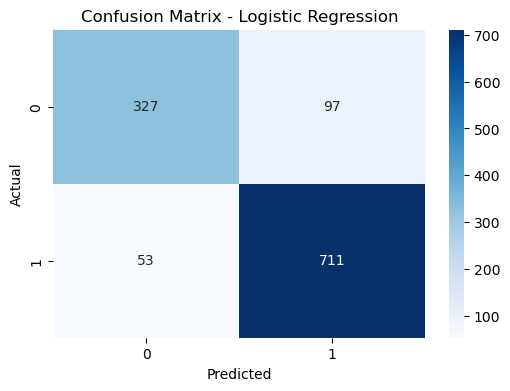

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [16]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Random Forest CV Accuracy:", rf_scores.mean())
print("Fold Scores:", rf_scores)

Random Forest CV Accuracy: 0.8847970701327188
Fold Scores: [0.88267148 0.89350181 0.87364621 0.88628159 0.88788427]


In [18]:
import joblib

joblib.dump(rf_model, "/Users/skush/CodeX/Stress-Level-Classifier/Models/random_forest_0.87.pkl")

['/Users/skush/CodeX/Stress-Level-Classifier/Models/random_forest_0.87.pkl']

In [20]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test_scaled)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.8845497258717772)